## Instructions

In this exercise, I used regression analysis to explore a dataset. 

## Setup

In [1]:
import numpy as np                     # Arrays and matrix functions
import pandas as pd                    # Data frames and functions
import matplotlib.pyplot as plt        # Plots
import seaborn as sns
import requests                        # Fetching data online
import statsmodels.api as sm           # Vectorized regression
import statsmodels.formula.api as smf  # Regression with formulas

# https://ipumspy.readthedocs.io/en/latest/index.html

## 1 Obtain IPUMS-CPS data - Downloaded from IPUMS

In [4]:
df = pd.read_csv(r"C:\Users\mattv\OneDrive\Documents\Academics\University of Southern California\04 - Fall 2022\03 - PPD 599 Special Topics (Python)\Problem Sets\cps_00009.csv") 
df

,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,ASECWT,AGE,SEX,MARST,FTOTVAL,ANYCOVLY
0,2021,1,3,20191202811300,1,687.71,1,20191202811301,687.71,56,2,1,27100,2
1,2021,1,3,20191202811300,1,687.71,2,20191202811302,687.71,57,1,1,27100,2
2,2021,1,3,20191202811300,1,687.71,3,20191202811303,646.86,78,2,5,27100,2
3,2021,2,3,20201202747700,1,1516.95,1,20201202747701,1516.95,65,2,1,106123,2
4,2021,2,3,20201202747700,1,1516.95,2,20201202747702,1516.95,66,1,1,106123,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163538,2021,90757,3,0,1,514.11,1,0,514.11,69,1,6,22093,2
163539,2021,90758,3,0,1,516.25,1,0,516.25,70,1,1,110800,2
163540,2021,90758,3,0,1,516.25,2,0,516.25,66,2,1,110800,2
163541,2021,90759,3,0,1,386.37,1,0,386.37,55,1,1,59803,2


## 2 Clean and prepare the data

I made the following further changes to the dataframe
 - Delete observations where variable `PERNUM` is not equal to 1; this retains only the main earner in each surveyed household.
 - Create a column called `female` equal to 1 if the respondent is female and 0 if they are not
 - Create a column called `married` equal to 1 if the respondent is married and 0 if they are not
 - Create a column called `has_health_insurance` equal 1 if if the household has health insurance and 0 if they do n ot
 - Drop respondents whose income is zero or negative
 - Drop respondents whose age is less than 20
 - Give the columns for total income, age, and marital status clearer labels
 - Delete all other columns from the data set except for the ones you've claend in this step.
 - Reset the row index so that observations are numbered 0 to N again.
 

In [5]:
#Delete observations where Pernum <> 1
df = df[df['PERNUM']!=1]

#Create column named female equal to 1 if female
df['female']=0
df.loc[df['SEX']==2,'female'] = 1

#Create column named married equal to 1 if married
df['married'] = 0 
df.loc[df['MARST']==1,'married'] = 1
df.loc[df['MARST']==2,'married'] = 1

#Create column named has_health_insurance equal to 1 if has health insurance
df['has_health_insurance']=0
df.loc[df['ANYCOVLY']==2,'has_health_insurance'] = 1

#Drop respondents whose income is zero or negative 
df = df[df['FTOTVAL']>0]

#Drop respondents whose age is less than 20 
df = df[df['AGE']>19]

#Give columns for total income, age, and marital status clearer labels
df = df.rename(columns={'FTOTVAL': 'Income', 'AGE': 'Respondent_Age', 'MARST': 'Marital_Status'})

#Delete all other columns except ones cleaned in this step 
df = df[['PERNUM','female','married','Marital_Status','has_health_insurance','Income','Respondent_Age']]

#Reset row index
df = df.reset_index()

C:\Users\mattv\AppData\Local\Temp\ipykernel_2244\227471522.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['female']=0
C:\Users\mattv\AppData\Local\Temp\ipykernel_2244\227471522.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['married'] = 0
C:\Users\mattv\AppData\Local\Temp\ipykernel_2244\227471522.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [6]:
df

,index,PERNUM,female,married,Marital_Status,has_health_insurance,Income,Respondent_Age
0,1,2,0,1,1,1,27100,57
1,2,3,1,0,5,1,27100,78
2,4,2,0,1,1,1,106123,66
3,5,3,0,0,6,1,106123,28
4,9,3,1,0,4,1,60000,48
...,...,...,...,...,...,...,...,...
53728,163533,3,0,0,6,0,165015,32
53729,163534,4,0,1,1,1,84800,33
53730,163535,5,1,1,1,1,84800,32
53731,163540,2,1,1,1,1,110800,66


## 3 Predicting income by age

I use `sm.OLS()` to predict income using least-squares regression on the age variable and a constant.

In [6]:
df['constant']=1

In [7]:
Income_on_Age = sm.OLS(df['Income'],df[['constant','Respondent_Age']]).fit()

In [8]:
Income_on_Age.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Income   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.009426
Date:                Fri, 14 Oct 2022   Prob (F-statistic):              0.923
Time:                        19:48:21   Log-Likelihood:            -7.0621e+05
No. Observations:               53733   AIC:                         1.412e+06
Df Residuals:                   53731   BIC:                         1.412e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
constant        1.132e+05   1506.020     75.170      0.000     1.1e+05    1.16e+05
Respondent_Age     2.9834     30.729      0.097      0.923     -57.246      63.212
==============================================================================
Omnibus:                    60139.669   Durbin-Watson:                   1.524
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          9734697.986
Skew:                           5.599   Prob(JB):                         0.00
Kurtosis:                      67.982   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 4 Predicting income by insurance status

I again predicted income, with `has_health_insurance` as my regressor. 

In [7]:
Income_on_Insurance = sm.OLS(df['Income'],df[['constant','has_health_insurance']]).fit()
Income_on_Insurance.summary()

KeyError: "['constant'] not in index"

## 5 Comparison with summary statistics

I used a `.groupby()` to calculate the average income for people with and without health insurance. 

In [12]:
df.groupby('has_health_insurance').mean().loc[:,'Income']

has_health_insurance
0     66326.260059
1    118968.411610
Name: Income, dtype: float64

In [13]:
print(118968.41 - 66326.26)

52642.15000000001


Average income is about $52,642.15 higher in the group with health insurance than the group without health insurance.

## 6 Income by insurance and age

Next, I used `sm.OLS` to regress income on age AND health insurance (and a constant). 

In [15]:
Two_on_Insurance = sm.OLS(df['Income'],df[['constant','has_health_insurance','Respondent_Age']]).fit()
Two_on_Insurance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Income   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     483.5
Date:                Fri, 14 Oct 2022   Prob (F-statistic):          7.57e-209
Time:                        19:48:23   Log-Likelihood:            -7.0573e+05
No. Observations:               53733   AIC:                         1.411e+06
Df Residuals:                   53730   BIC:                         1.411e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
constant              7.146e+04   2007.515     35.597      0.000    6.75e+04    7.54e+04
has_health_insurance   5.37e+04   1726.741     31.097      0.000    5.03e+04    5.71e+04
Respondent_Age        -132.5794     30.767     -4.309      0.000    -192.883     -72.276
==============================================================================
Omnibus:                    60761.778   Durbin-Watson:                   1.540
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         10333933.227
Skew:                           5.687   Prob(JB):                         0.00
Kurtosis:                      69.980   Cond. No.                         225.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Previously we saw a positive relationship between age and income. Holding health insurance constant, we can see that age now has a negative relationship with income. 

## 7 Income by age, gender, marital status

Now, let's make a more complicated prediction model. Regress *the natural logarithm of income* on age, a set of dummies for marital status interacted with sex, and a quadratic of age (that is, age plus its square). Use `smf.ols()` to write a formula for this model. Use `C()`, `I()` and numpy functions to transform the relevant variables.

In [8]:
Q7 = smf.ols('np.log(Income) ~ Respondent_Age + C(female)*C(Marital_Status) + I(Respondent_Age**2)', data=df).fit()
Q7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         np.log(Income)   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     310.4
Date:                Mon, 20 Nov 2023   Prob (F-statistic):               0.00
Time:                        14:07:19   Log-Likelihood:                -79974.
No. Observations:               53733   AIC:                         1.600e+05
Df Residuals:                   53719   BIC:                         1.601e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                11.2315      0.044    252.644      0.000      11.144      11.319
C(female)[T.1]                            0.0462      0.012      3.884      0.000       0.023       0.070
C(Marital_Status)[T.2]                   -0.4738      0.064     -7.420      0.000      -0.599      -0.349
C(Marital_Status)[T.3]                   -0.7128      0.068    -10.418      0.000      -0.847      -0.579
C(Marital_Status)[T.4]                   -0.7193      0.031    -23.113      0.000      -0.780      -0.658
C(Marital_Status)[T.5]                   -0.2653      0.062     -4.309      0.000      -0.386      -0.145
C(Marital_Status)[T.6]                   -0.4533      0.017    -26.607      0.000      -0.487      -0.420
C(female)[T.1]:C(Marital_Status)[T.2]    -0.1737      0.090     -1.932      0.053      -0.350       0.002
C(female)[T.1]:C(Marital_Status)[T.3]    -0.2291      0.092     -2.479      0.013      -0.410      -0.048
C(female)[T.1]:C(Marital_Status)[T.4]    -0.0904      0.042     -2.162      0.031      -0.172      -0.008
C(female)[T.1]:C(Marital_Status)[T.5]     0.0599      0.070      0.858      0.391      -0.077       0.197
C(female)[T.1]:C(Marital_Status)[T.6]    -0.2090      0.021     -9.862      0.000      -0.251      -0.167
Respondent_Age                            0.0147      0.002      8.289      0.000       0.011       0.018
I(Respondent_Age ** 2)                   -0.0002   1.72e-05    -12.280      0.000      -0.000      -0.000
==============================================================================
Omnibus:                    34222.917   Durbin-Watson:                   1.556
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           978975.610
Skew:                          -2.613   Prob(JB):                         0.00
Kurtosis:                      23.247   Cond. No.                     6.92e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.92e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 8 In-sample predicted values

I created a new column equal to the log of incomee and predicted in-sample log-income from my previous regression model. 

In [18]:
df['LogIncome'] = np.log(df['Income'])
df

,index,PERNUM,female,married,Marital_Status,has_health_insurance,Income,Respondent_Age,constant,LogIncome
0,1,2,0,1,1,1,27100,57,1,10.207289
1,2,3,1,0,5,1,27100,78,1,10.207289
2,4,2,0,1,1,1,106123,66,1,11.572354
3,5,3,0,0,6,1,106123,28,1,11.572354
4,9,3,1,0,4,1,60000,48,1,11.002100
...,...,...,...,...,...,...,...,...,...,...
53728,163533,3,0,0,6,0,165015,32,1,12.013792
53729,163534,4,0,1,1,1,84800,33,1,11.348051
53730,163535,5,1,1,1,1,84800,32,1,11.348051
53731,163540,2,1,1,1,1,110800,66,1,11.615482


In [19]:
df['predicted_LogIncome'] = Q7.predict()
df['residuals']=df['LogIncome']-df['predicted_LogIncome']
df.head(10)

,index,PERNUM,female,married,Marital_Status,has_health_insurance,Income,Respondent_Age,constant,LogIncome,predicted_LogIncome,residuals
0,1,2,0,1,1,1,27100,57,1,10.207289,11.382035,-1.174746
1,2,3,1,0,5,1,27100,78,1,10.207289,10.932231,-0.724942
2,4,2,0,1,1,1,106123,66,1,11.572354,11.280290,0.292064
3,5,3,0,0,6,1,106123,28,1,11.572354,11.023735,0.548619
4,9,3,1,0,4,1,60000,48,1,11.002100,10.686114,0.315986
5,15,2,1,0,6,1,233467,49,1,12.360796,10.827683,1.533113
6,16,3,0,0,6,1,233467,20,1,12.360796,10.987391,1.373405
7,19,2,0,1,1,1,140416,58,1,11.852365,11.372421,0.479944
8,23,2,0,1,1,1,115000,44,1,11.652687,11.468567,0.184121
9,29,2,1,1,2,1,25000,44,1,10.126631,10.867284,-0.740653


## 9 Predictions for hypothetical cases

I used `.predict()` to generate predicted incomes for
- a 25-year-old single woman
- a 40-year-old married man
- a 99-year-old widowed man

Recall that the values for marital status correspond to

`MARST               Marital status
1                   Married, spouse present
2                   Married, spouse absent
3                   Separated
4                   Divorced
5                   Widowed
6                   Never married/single
7                   Widowed or Divorced
9                   NIU`




In [21]:
Q9 = pd.DataFrame([[25,1,1],[40,0,1],[99,0,5]], columns=['Respondent_Age','female','Marital_Status'])

Q7.predict(Q9)

0    11.512807
1    11.480823
2    10.349025
dtype: float64

## 10 Regression plots

I created a matrix of regression plots with 
1. log of income on the vertical axis
2. age on the horizontal axis
3. markers colored by sex
4. separated into different plots by
    + health insurance status and by
    + married / unmarried status

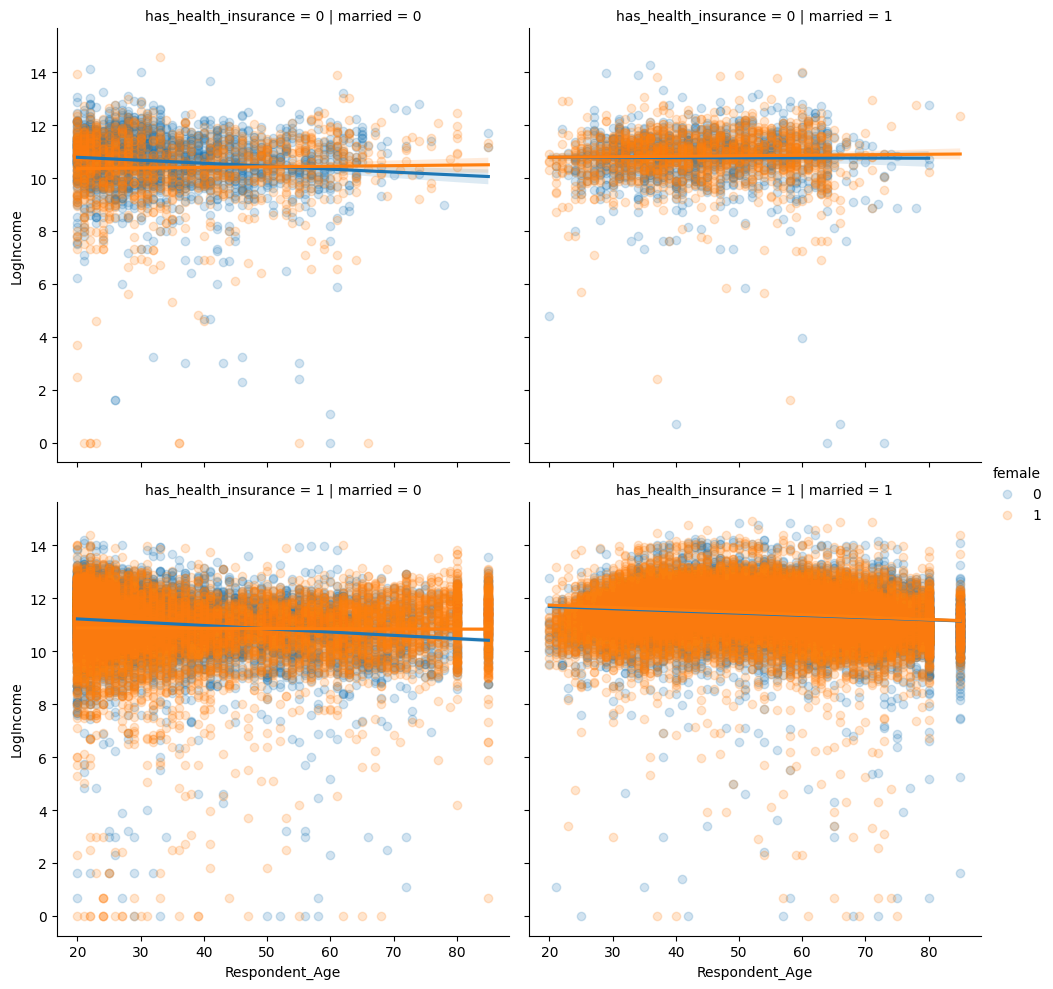

In [28]:
sns.lmplot(data=df,x='Respondent_Age',y='LogIncome',hue='female',col='married',row='has_health_insurance',scatter_kws={'alpha':0.2})
plt.show()